In [51]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline as SkPipeline

# Scikit-learn - metrics
from sklearn.metrics import (
    accuracy_score, classification_report, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, recall_score, f1_score
)

# imbalanced-learn - SMOTE resampling
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [20]:
df = pd.read_csv('../data/bank.csv', sep=';')

In [21]:
#drop duration
df = df.drop(columns=['duration'])

#encode as binary
df['y'] = (df['y'] == 'yes').astype(int)

#change pdays to binary because 999 implies no prior contact, changing it to 0 might skew the model
df['p_contacted'] = (df['pdays'] != 999).astype(int)
df = df.drop(columns=['pdays'])  



In [22]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [23]:
X = df.drop('y', axis=1, inplace=False)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Dummy Classifier
Determine Baseline

In [25]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
)

dummy_pipe = SkPipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent', random_state=42)),
])

dummy_pipe.fit(X_train, y_train)
y_pred_dummy = dummy_pipe.predict(X_test)
y_prob_dummy = dummy_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dummy):.4f}")
print()
print(classification_report(y_test, y_pred_dummy, target_names=['no', 'yes']))

Accuracy : 0.8895
ROC-AUC  : 0.5000

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      1006
         yes       0.00      0.00      0.00       125

    accuracy                           0.89      1131
   macro avg       0.44      0.50      0.47      1131
weighted avg       0.79      0.89      0.84      1131



### SMOTE - Synthetic Minority Oversampling Technique

The training set has a significant class imbalance (~7:1 ratio of *no* to *yes*). Classifiers trained on this raw distribution are biased toward predicting the majority class, producing high accuracy but very poor recall on the minority class - the *yes* subscribers we actually care about.

**SMOTE** addresses this by synthesising new minority-class examples rather than simply duplicating existing ones:
1. For each minority sample, find its *k* nearest minority neighbours (in feature space).
2. Randomly interpolate between the sample and one of those neighbours to create a new synthetic point.
3. Repeat until the classes are balanced.

**Key implementation details used here:**
- SMOTE is inserted as a pipeline step **after** `OneHotEncoder`, so it always operates on a fully numeric feature matrix.
- Using `ImbPipeline` (from `imbalanced-learn`) ensures SMOTE is applied **only inside training folds** during cross-validation - the test set is never touched, keeping evaluation unbiased.
- `k_neighbors` is included in the `GridSearchCV` param grid to find the best neighbourhood size alongside model hyperparameters.

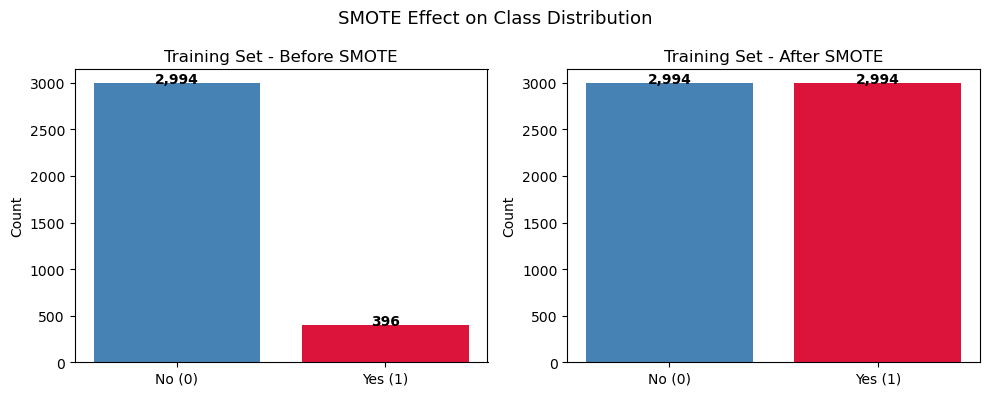

Before - No: 2,994  Yes: 396  (ratio 7.6:1)
After  - No: 2,994   Yes: 2,994   (ratio 1.0:1)


In [26]:
# Show how SMOTE rebalances the training set
_pre = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
)
X_train_enc = _pre.fit_transform(X_train)
_, y_resampled = SMOTE(random_state=42).fit_resample(X_train_enc, y_train)

before = y_train.value_counts().sort_index()
after  = pd.Series(y_resampled).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes, [before, after], ['Before SMOTE', 'After SMOTE']):
    ax.bar(['No (0)', 'Yes (1)'], counts.values, color=['steelblue', 'crimson'])
    ax.set_title(f'Training Set - {title}')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 2, f'{v:,}', ha='center', fontweight='bold')
plt.suptitle('SMOTE Effect on Class Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Before - No: {before[0]:,}  Yes: {before[1]:,}  (ratio {before[0]/before[1]:.1f}:1)")
print(f"After  - No: {after[0]:,}   Yes: {after[1]:,}   (ratio {after[0]/after[1]:.1f}:1)")

### Logistic Regression Pipeline
Build a full preprocessing + model pipeline using `StandardScaler` for numeric features and `OneHotEncoder` for categorical features.

In [27]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

preprocessor = make_column_transformer(
    (StandardScaler(), num_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols),
)

lr_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, random_state=42)),
])

lr_pipe.fit(X_train, y_train)
y_pred = lr_pipe.predict(X_test)
y_prob = lr_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_prob):.4f}")
print(f"Recall (yes): {recall_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

Accuracy    : 0.6976
ROC-AUC     : 0.7011
Recall (yes): 0.5200

              precision    recall  f1-score   support

          no       0.92      0.72      0.81      1006
         yes       0.19      0.52      0.28       125

    accuracy                           0.70      1131
   macro avg       0.56      0.62      0.54      1131
weighted avg       0.84      0.70      0.75      1131



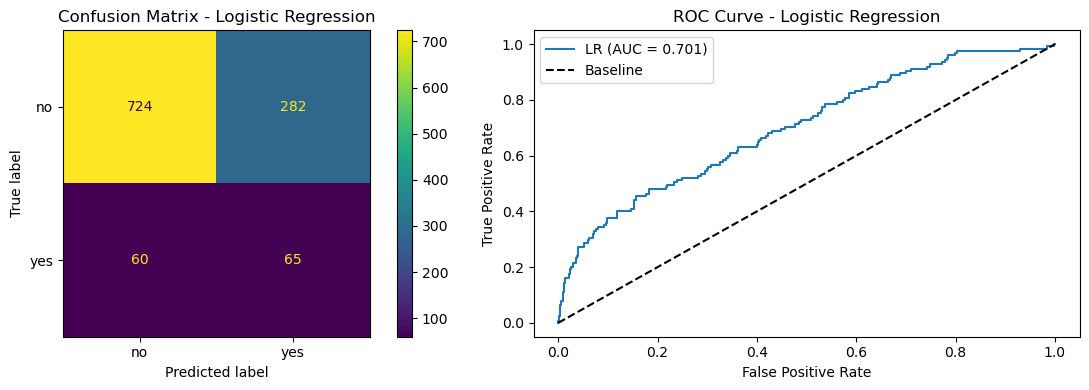

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'LR (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()

### Logistic Regression - Stratified K-Fold Cross-Validation
Evaluate the same pipeline with 5-fold stratified cross-validation to get a more robust estimate of generalisation performance.

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(lr_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc  = cross_val_score(lr_pipe, X, y, cv=skf, scoring='roc_auc')

print("Logistic Regression - 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy.mean():.4f}  (+/- {cv_accuracy.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc.mean():.4f}  (+/- {cv_roc_auc.std():.4f})")

cv_results = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy,
    'ROC-AUC': cv_roc_auc,
})
print()
print(cv_results.to_string(index=False))

Logistic Regression - 5-Fold Stratified CV
  Accuracy : 0.6954  (+/- 0.0176)
  ROC-AUC  : 0.7145  (+/- 0.0267)

 Fold  Accuracy  ROC-AUC
    1  0.661878 0.724345
    2  0.698009 0.689615
    3  0.706858 0.705240
    4  0.698009 0.761719
    5  0.712389 0.691370


### K-Nearest Neighbors Pipeline
Same preprocessing pipeline with `KNeighborsClassifier` as the estimator.

In [30]:
knn_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier()),
])

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
y_prob_knn = knn_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy    : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_prob_knn):.4f}")
print(f"Recall (yes): {recall_score(y_test, y_pred_knn):.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['no', 'yes']))

Accuracy    : 0.6729
ROC-AUC     : 0.6208
Recall (yes): 0.4960

              precision    recall  f1-score   support

          no       0.92      0.69      0.79      1006
         yes       0.17      0.50      0.25       125

    accuracy                           0.67      1131
   macro avg       0.54      0.60      0.52      1131
weighted avg       0.83      0.67      0.73      1131



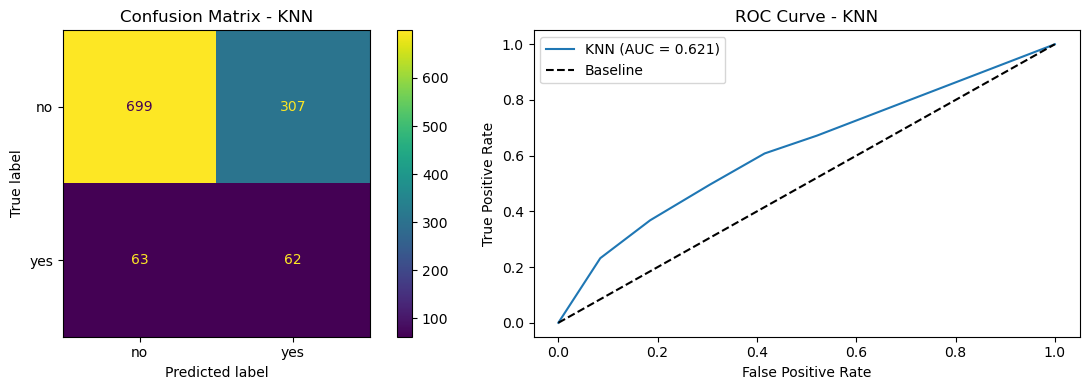

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix - KNN')

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)
axes[1].plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - KNN')
axes[1].legend()

plt.tight_layout()
plt.show()

### KNN - Stratified K-Fold Cross-Validation

In [32]:
cv_accuracy_knn = cross_val_score(knn_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_knn  = cross_val_score(knn_pipe, X, y, cv=skf, scoring='roc_auc')

print("KNN - 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_knn.mean():.4f}  (+/- {cv_accuracy_knn.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_knn.mean():.4f}  (+/- {cv_roc_auc_knn.std():.4f})")

cv_results_knn = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_knn,
    'ROC-AUC': cv_roc_auc_knn,
})
print()
print(cv_results_knn.to_string(index=False))

KNN - 5-Fold Stratified CV
  Accuracy : 0.6934  (+/- 0.0117)
  ROC-AUC  : 0.6583  (+/- 0.0204)

 Fold  Accuracy  ROC-AUC
    1  0.702762 0.693714
    2  0.690265 0.655391
    3  0.695796 0.629675
    4  0.672566 0.656995
    5  0.705752 0.655715


### Decision Tree Pipeline

In [33]:
dt_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(random_state=42)),
])

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
y_prob_dt = dt_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy    : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"Recall (yes): {recall_score(y_test, y_pred_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['no', 'yes']))

Accuracy    : 0.8117
ROC-AUC     : 0.6034
Recall (yes): 0.3360

              precision    recall  f1-score   support

          no       0.91      0.87      0.89      1006
         yes       0.24      0.34      0.28       125

    accuracy                           0.81      1131
   macro avg       0.58      0.60      0.59      1131
weighted avg       0.84      0.81      0.82      1131



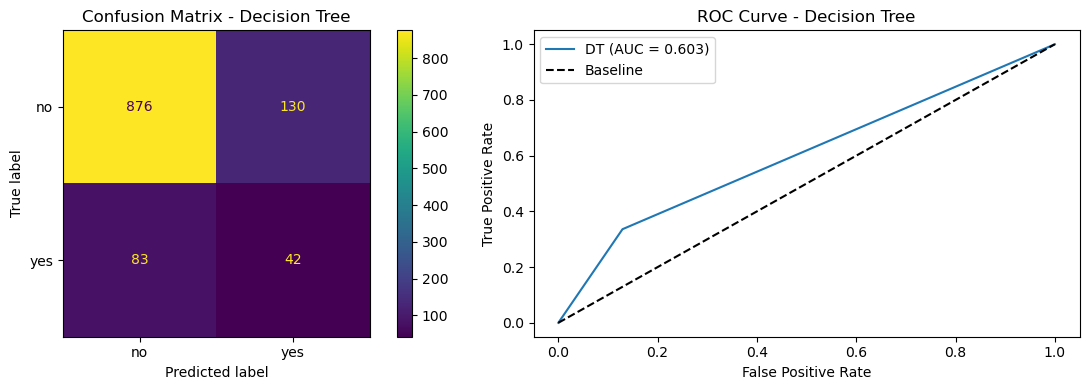

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
axes[1].plot(fpr_dt, tpr_dt, label=f'DT (AUC = {auc_dt:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Decision Tree')
axes[1].legend()

plt.tight_layout()
plt.show()

### Decision Tree - Stratified K-Fold Cross-Validation

In [35]:
cv_accuracy_dt = cross_val_score(dt_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_dt  = cross_val_score(dt_pipe, X, y, cv=skf, scoring='roc_auc')

print("Decision Tree - 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_dt.mean():.4f}  (+/- {cv_accuracy_dt.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_dt.mean():.4f}  (+/- {cv_roc_auc_dt.std():.4f})")

cv_results_dt = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_dt,
    'ROC-AUC': cv_roc_auc_dt,
})
print()
print(cv_results_dt.to_string(index=False))

Decision Tree - 5-Fold Stratified CV
  Accuracy : 0.8160  (+/- 0.0083)
  ROC-AUC  : 0.5947  (+/- 0.0141)

 Fold  Accuracy  ROC-AUC
    1  0.803315 0.570208
    2  0.826327 0.596538
    3  0.816372 0.590913
    4  0.823009 0.611394
    5  0.810841 0.604519


### Support Vector Machine Pipeline

In [36]:
svm_pipe = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', SVC(kernel='linear', probability=True, random_state=42)),
])

svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
y_prob_svm = svm_pipe.predict_proba(X_test)[:, 1]

print(f"Accuracy    : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC     : {roc_auc_score(y_test, y_prob_svm):.4f}")
print(f"Recall (yes): {recall_score(y_test, y_pred_svm):.4f}")
print()
print(classification_report(y_test, y_pred_svm, target_names=['no', 'yes']))

Accuracy    : 0.7179
ROC-AUC     : 0.7001
Recall (yes): 0.5200

              precision    recall  f1-score   support

          no       0.93      0.74      0.82      1006
         yes       0.20      0.52      0.29       125

    accuracy                           0.72      1131
   macro avg       0.56      0.63      0.56      1131
weighted avg       0.85      0.72      0.76      1131



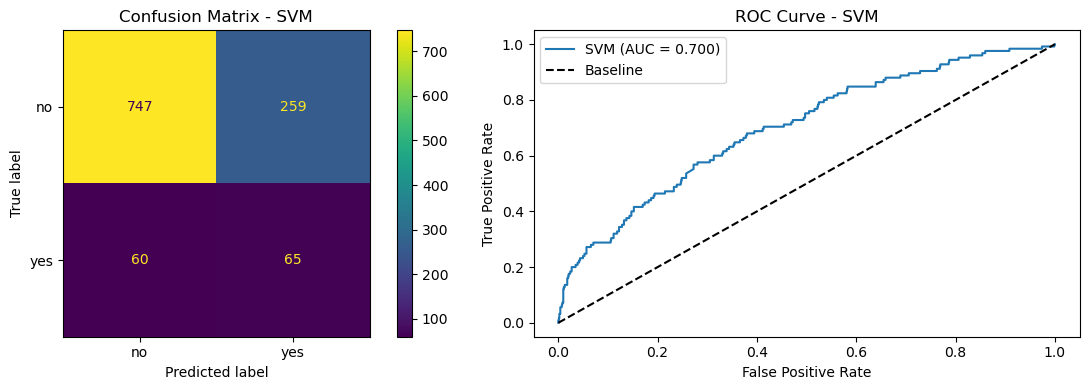

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=['no', 'yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix - SVM')

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)
axes[1].plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - SVM')
axes[1].legend()

plt.tight_layout()
plt.show()

### SVM - Stratified K-Fold Cross-Validation

In [38]:
cv_accuracy_svm = cross_val_score(svm_pipe, X, y, cv=skf, scoring='accuracy')
cv_roc_auc_svm  = cross_val_score(svm_pipe, X, y, cv=skf, scoring='roc_auc')

print("SVM - 5-Fold Stratified CV")
print(f"  Accuracy : {cv_accuracy_svm.mean():.4f}  (+/- {cv_accuracy_svm.std():.4f})")
print(f"  ROC-AUC  : {cv_roc_auc_svm.mean():.4f}  (+/- {cv_roc_auc_svm.std():.4f})")

cv_results_svm = pd.DataFrame({
    'Fold': range(1, 6),
    'Accuracy': cv_accuracy_svm,
    'ROC-AUC': cv_roc_auc_svm,
})
print()
print(cv_results_svm.to_string(index=False))

SVM - 5-Fold Stratified CV
  Accuracy : 0.6828  (+/- 0.0296)
  ROC-AUC  : 0.7019  (+/- 0.0267)

 Fold  Accuracy  ROC-AUC
    1  0.639779 0.712476
    2  0.655973 0.676755
    3  0.702434 0.679279
    4  0.699115 0.748966
    5  0.716814 0.691959


### GridSearchCV - Hyperparameter Tuning: Baseline vs SMOTE

Two `GridSearchCV` runs are performed back-to-back using the same `StratifiedKFold` splits:

- **Baseline** - vanilla `SkPipeline` (no resampling), identical param grids to before.
- **SMOTE** - `ImbPipeline` with `smote__k_neighbors [3, 5, 7]` tuned alongside model hyperparameters.

Results are compared side-by-side on **CV ROC-AUC**, **Test ROC-AUC**, and **minority-class recall** - the metric that most clearly shows whether SMOTE is helping the model identify actual subscribers.

In [ ]:

base_pipes = {
    'Logistic Regression': SkPipeline([('preprocessor', preprocessor), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'KNN':                 SkPipeline([('preprocessor', preprocessor), ('model', KNeighborsClassifier())]),
    'Decision Tree':       SkPipeline([('preprocessor', preprocessor), ('model', DecisionTreeClassifier(random_state=42))]),
    'SVM':                 SkPipeline([('preprocessor', preprocessor), ('model', SVC(kernel='linear', probability=True, random_state=42))]),
}

base_param_grids = {
    'Logistic Regression': {
        'model__C':      [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs', 'liblinear'],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 11, 21],
        'model__weights':     ['uniform', 'distance'],
        'model__metric':      ['euclidean', 'manhattan'],
    },
    'Decision Tree': {
        'model__max_depth':         [3, 5, 10, None],
        'model__min_samples_split': [2, 10, 20],
        'model__criterion':         ['gini', 'entropy'],
    },
    'SVM': {
        'model__C':      [0.1, 1, 10],
        'model__kernel': ['poly', 'linear', 'sigmoid'],
        'model__gamma':  ['scale', 'auto'],
    },
}

## == Used Gen AI to help with smote pipeline
smote_pipes = {
    'Logistic Regression': lr_pipe,
    'KNN':                 knn_pipe,
    'Decision Tree':       dt_pipe,
    'SVM':                 svm_pipe,
}

smote_param_grids = {
    'Logistic Regression': {
        'smote__k_neighbors': [3, 5, 7],
        'model__C':           [0.01, 0.1, 1, 10],
        'model__solver':      ['lbfgs', 'liblinear'],
    },
    'KNN': {
        'smote__k_neighbors':  [3, 5, 7],
        'model__n_neighbors':  [3, 5, 11, 21],
        'model__weights':      ['uniform', 'distance'],
        'model__metric':       ['euclidean', 'manhattan'],
    },
    'Decision Tree': {
        'smote__k_neighbors':       [3, 5, 7],
        'model__max_depth':         [3, 5, 10, None],
        'model__min_samples_split': [2, 10, 20],
        'model__criterion':         ['gini', 'entropy'],
    },
    'SVM': {
        'smote__k_neighbors': [3, 5, 7],
        'model__C':           [0.1, 1, 10],
        'model__kernel':      ['poly', 'linear', 'sigmoid'],
        'model__gamma':       ['scale', 'auto'],
    },
}


def run_gridsearch(pipes, param_grids, label):
    results = []
    for name in pipes:
        print(f"[{label}] Tuning {name}...")
        start = time.time()
        gs = GridSearchCV(pipes[name], param_grids[name], cv=skf, scoring='roc_auc', n_jobs=-1, refit=True)
        gs.fit(X_train, y_train)
        elapsed = time.time() - start

        best_est = gs.best_estimator_
        t0 = time.time(); best_est.fit(X_train, y_train); train_time = time.time() - t0
        t0 = time.time(); y_pred_gs = best_est.predict(X_test); predict_time = time.time() - t0
        y_prob_gs = best_est.predict_proba(X_test)[:, 1]

        results.append({
            'Model':            name,
            'Best Params':      gs.best_params_,
            'CV ROC-AUC':       round(gs.best_score_, 4),
            'Test Accuracy':    round(accuracy_score(y_test, y_pred_gs), 4),
            'Test ROC-AUC':     round(roc_auc_score(y_test, y_prob_gs), 4),
            'Recall (yes)':     round(recall_score(y_test, y_pred_gs), 4),
            'GridSearch (s)':   round(elapsed, 2),
            'Train Time (s)':   round(train_time, 4),
            'Predict Time (s)': round(predict_time, 4),
            'best_estimator':   best_est,
            'y_pred':           y_pred_gs,
            'y_prob':           y_prob_gs,
        })
        print(f"  Best params  : {gs.best_params_}")
        print(f"  CV ROC-AUC   : {gs.best_score_:.4f}")
        print(f"  Test Acc     : {accuracy_score(y_test, y_pred_gs):.4f}")
        print(f"  Test ROC-AUC : {roc_auc_score(y_test, y_prob_gs):.4f}")
        print(f"  Recall (yes) : {recall_score(y_test, y_pred_gs):.4f}")
        print(f"  GridSearch   : {elapsed:.2f}s")
        print(f"  Train time   : {train_time:.4f}s")
        print(f"  Predict time : {predict_time:.4f}s")
        print()
    return results


print("=" * 60)
print("BASELINE (no resampling)")
print("=" * 60)
gs_base_results = run_gridsearch(base_pipes, base_param_grids, "Base")

print("=" * 60)
print("SMOTE (k_neighbors tuned)")
print("=" * 60)
gs_smote_results = run_gridsearch(smote_pipes, smote_param_grids, "SMOTE")

BASELINE (no resampling)
[Base] Tuning Logistic Regression...
  Best params  : {'model__C': 0.1, 'model__solver': 'liblinear'}
  CV ROC-AUC   : 0.7304
  Test Acc     : 0.8939
  Test ROC-AUC : 0.6966
  Recall (yes) : 0.0800
  GridSearch   : 3.84s
  Train time   : 0.0144s
  Predict time : 0.0050s

[Base] Tuning KNN...
  Best params  : {'model__metric': 'euclidean', 'model__n_neighbors': 21, 'model__weights': 'uniform'}
  CV ROC-AUC   : 0.6855
  Test Acc     : 0.8895
  Test ROC-AUC : 0.6725
  Recall (yes) : 0.0080
  GridSearch   : 0.72s
  Train time   : 0.0122s
  Predict time : 0.0180s

[Base] Tuning Decision Tree...
  Best params  : {'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_split': 10}
  CV ROC-AUC   : 0.6767
  Test Acc     : 0.8948
  Test ROC-AUC : 0.6430
  Recall (yes) : 0.1840
  GridSearch   : 0.46s
  Train time   : 0.0149s
  Predict time : 0.0039s

[Base] Tuning SVM...
  Best params  : {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'poly'}
 

In [40]:
exclude_keys = ('Best Params', 'best_estimator', 'y_pred', 'y_prob')

base_df  = pd.DataFrame([{k: v for k, v in r.items() if k not in exclude_keys} for r in gs_base_results])
smote_df = pd.DataFrame([{k: v for k, v in r.items() if k not in exclude_keys} for r in gs_smote_results])

print("Baseline (no resampling)")
print(base_df.to_string(index=False))
print()
print("SMOTE")
print(smote_df.to_string(index=False))

Baseline (no resampling)
              Model  CV ROC-AUC  Test Accuracy  Test ROC-AUC  Recall (yes)  GridSearch (s)  Train Time (s)  Predict Time (s)
Logistic Regression      0.7304         0.8939        0.6966         0.080            3.84          0.0144            0.0050
                KNN      0.6855         0.8895        0.6725         0.008            0.72          0.0122            0.0180
      Decision Tree      0.6767         0.8948        0.6430         0.184            0.46          0.0149            0.0039
                SVM      0.6849         0.8886        0.6493         0.000            5.46          0.5007            0.0227

SMOTE
              Model  CV ROC-AUC  Test Accuracy  Test ROC-AUC  Recall (yes)  GridSearch (s)  Train Time (s)  Predict Time (s)
Logistic Regression      0.7228         0.6676        0.7021         0.608            0.86          0.0325            0.0045
                KNN      0.6950         0.5853        0.6652         0.640            1.52   

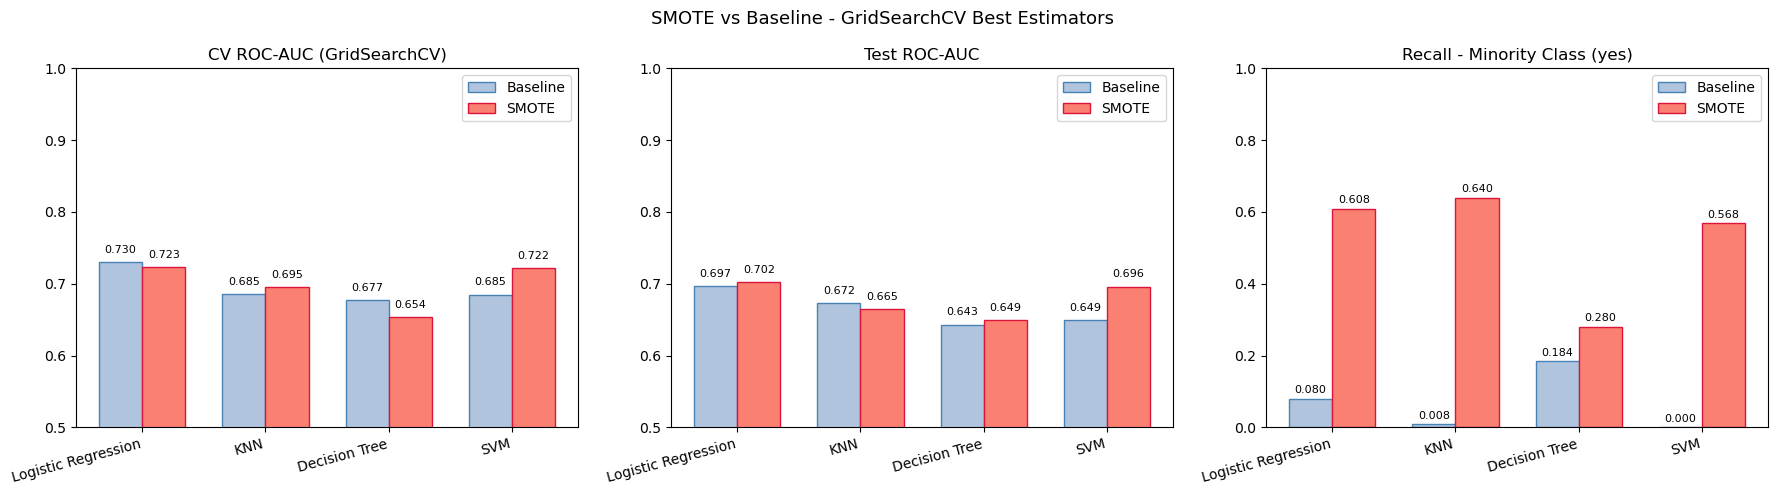

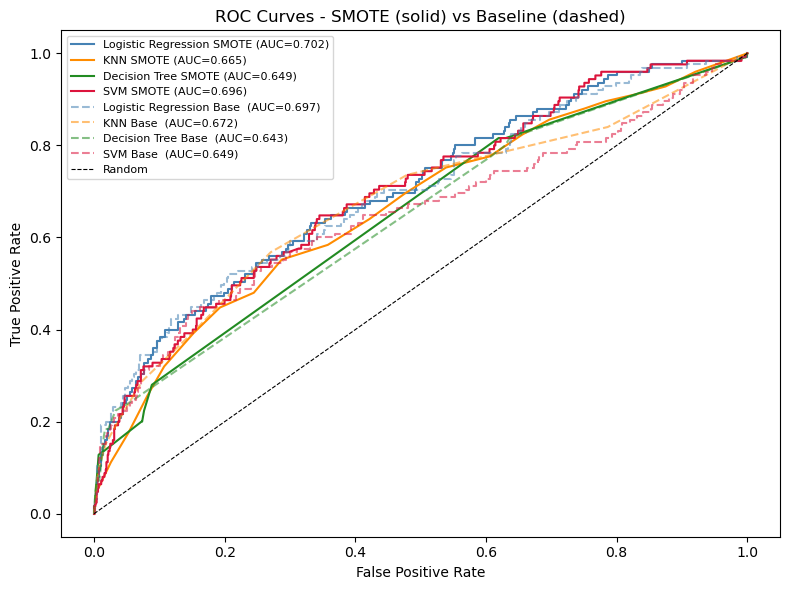

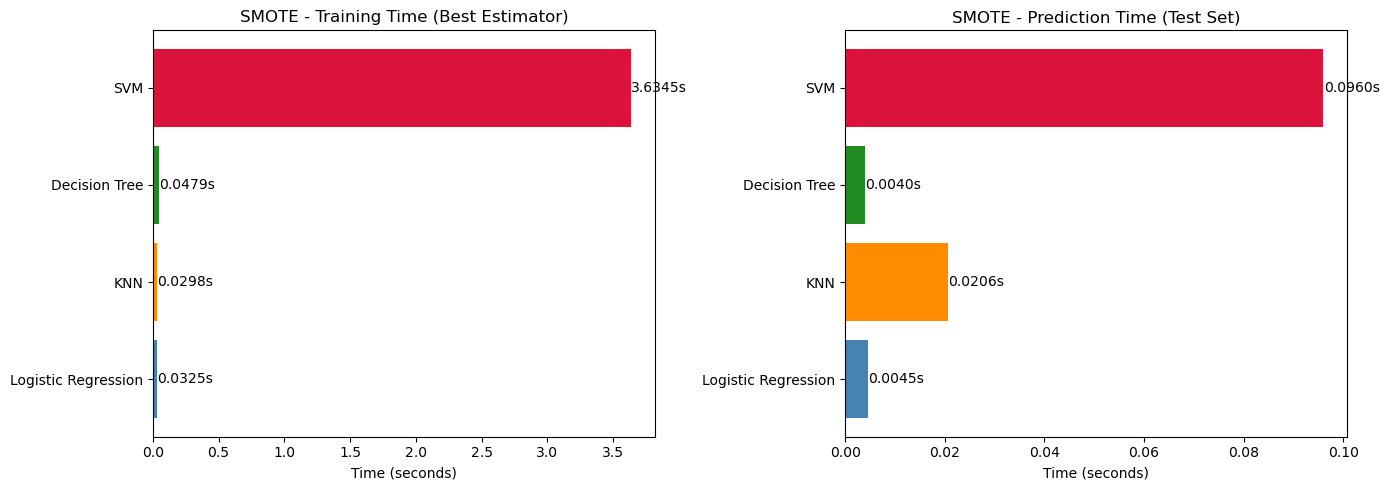

SMOTE Results - Callout Summary
  Best minority-class recall : KNN
  Best Test ROC-AUC          : Logistic Regression
  Fastest to train           : KNN
  Slowest to train           : SVM
  Fastest to predict         : Decision Tree
  Slowest to predict         : SVM

Minority-class recall improvement (SMOTE Ã¢Ë†â€™ Baseline):
  Logistic Regression   : 0.0800 Ã¢â€ â€™ 0.6080  (+0.5280)
  KNN                   : 0.0080 Ã¢â€ â€™ 0.6400  (+0.6320)
  Decision Tree         : 0.1840 Ã¢â€ â€™ 0.2800  (+0.0960)
  SVM                   : 0.0000 Ã¢â€ â€™ 0.5680  (+0.5680)


In [50]:
colors     = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
model_names = [r['Model'] for r in gs_smote_results]
x     = np.arange(len(model_names))
width = 0.35

metrics = [
    ('CV ROC-AUC',   'CV ROC-AUC (GridSearchCV)',    0.5, 1.0),
    ('Test ROC-AUC', 'Test ROC-AUC',                 0.5, 1.0),
    ('Recall (yes)', 'Recall - Minority Class (yes)', 0.0, 1.0),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (metric, title, ymin, ymax) in zip(axes, metrics):
    base_vals  = base_df[metric].values
    smote_vals = smote_df[metric].values
    bars1 = ax.bar(x - width/2, base_vals,  width, label='Baseline', color='lightsteelblue', edgecolor='steelblue')
    bars2 = ax.bar(x + width/2, smote_vals, width, label='SMOTE',    color='salmon',         edgecolor='crimson')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim(ymin, ymax)
    ax.set_title(title)
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('SMOTE vs Baseline - GridSearchCV Best Estimators', fontsize=13)
plt.tight_layout()
plt.show()

# - ROC curves: SMOTE (solid) vs Baseline (dashed) ------------
fig, ax = plt.subplots(figsize=(8, 6))
for r, color in zip(gs_smote_results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, linestyle='-',
            label=f"{r['Model']} SMOTE (AUC={r['Test ROC-AUC']:.3f})")
for r, color in zip(gs_base_results, colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fpr, tpr, color=color, linestyle='--', alpha=0.55,
            label=f"{r['Model']} Base  (AUC={r['Test ROC-AUC']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - SMOTE (solid) vs Baseline (dashed)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_times   = smote_df['Train Time (s)']
predict_times = smote_df['Predict Time (s)']

axes[0].barh(smote_df['Model'], train_times, color=colors)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_title('SMOTE - Training Time (Best Estimator)')
for i, v in enumerate(train_times):
    axes[0].text(v + 0.0005, i, f'{v:.4f}s', va='center')

axes[1].barh(smote_df['Model'], predict_times, color=colors)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_title('SMOTE - Prediction Time (Test Set)')
for i, v in enumerate(predict_times):
    axes[1].text(v + 0.0001, i, f'{v:.4f}s', va='center')

plt.tight_layout()
plt.show()

fastest_train = smote_df.loc[smote_df['Train Time (s)'].idxmin(), 'Model']
slowest_train = smote_df.loc[smote_df['Train Time (s)'].idxmax(), 'Model']
fastest_pred  = smote_df.loc[smote_df['Predict Time (s)'].idxmin(), 'Model']
slowest_pred  = smote_df.loc[smote_df['Predict Time (s)'].idxmax(), 'Model']
best_recall   = smote_df.loc[smote_df['Recall (yes)'].idxmax(), 'Model']
best_auc      = smote_df.loc[smote_df['Test ROC-AUC'].idxmax(), 'Model']

print("SMOTE Results - Callout Summary")
print("=" * 50)
print(f"  Best minority-class recall : {best_recall}")
print(f"  Best Test ROC-AUC          : {best_auc}")
print(f"  Fastest to train           : {fastest_train}")
print(f"  Slowest to train           : {slowest_train}")
print(f"  Fastest to predict         : {fastest_pred}")
print(f"  Slowest to predict         : {slowest_pred}")
print()

# Recall delta (SMOTE gain over baseline)
print("Minority-class recall improvement (SMOTE Ã¢Ë†â€™ Baseline):")
for _, b_row in base_df.iterrows():
    s_row = smote_df[smote_df['Model'] == b_row['Model']].iloc[0]
    delta = s_row['Recall (yes)'] - b_row['Recall (yes)']
    direction = '+' if delta >= 0 else ''
    print(f"  {b_row['Model']:<22}: {b_row['Recall (yes)']:.4f} Ã¢â€ â€™ {s_row['Recall (yes)']:.4f}  ({direction}{delta:.4f})")

### Generalisation Test - Predict on `bank-full.csv`
The models were trained on the small `bank.csv` dataset (~4,500 rows). Here we load the full dataset (`bank-full.csv`, ~45,000 rows), apply identical preprocessing, and score each model - comparing the **baseline** (no resampling) against the **SMOTE** variant - to see how well both generalise to unseen, full-scale data.

In [47]:
# Load and preprocess bank-full.csv with the same steps used on bank.csv
df_full = pd.read_csv('../data/bank-full.csv', sep=';')

df_full = df_full.drop(columns=['duration'])
df_full['y'] = (df_full['y'] == 'yes').astype(int)
df_full['p_contacted'] = (df_full['pdays'] != 999).astype(int)
df_full = df_full.drop(columns=['pdays'])

X_full = df_full.drop('y', axis=1)
y_full = df_full['y']

print(f'bank-full.csv - {X_full.shape[0]:,} rows, {X_full.shape[1]} features')
print(f'Class balance: {y_full.value_counts().to_dict()}')

bank-full.csv - 45,211 rows, 15 features
Class balance: {0: 39922, 1: 5289}


In [44]:
# Score baseline and SMOTE best estimators on bank-full.csv
rows = []
for base_res, smote_res in zip(gs_base_results, gs_smote_results):
    name = base_res['Model']

    for label, est in [('Baseline', base_res['best_estimator']),
                        ('SMOTE',    smote_res['best_estimator'])]:
        y_pred_full = est.predict(X_full)
        y_prob_full = est.predict_proba(X_full)[:, 1]
        rows.append({
            'Model':        name,
            'Type':         label,
            'Accuracy':     round(accuracy_score(y_full, y_pred_full), 4),
            'ROC-AUC':      round(roc_auc_score(y_full, y_prob_full), 4),
            'Recall (yes)': round(recall_score(y_full, y_pred_full), 4),
            'F1 (yes)':     round(f1_score(y_full, y_pred_full), 4),
        })

results_full = pd.DataFrame(rows)
print('Generalisation scores on bank-full.csv')
print(results_full.to_string(index=False))

Generalisation scores on bank-full.csv
              Model     Type  Accuracy  ROC-AUC  Recall (yes)  F1 (yes)
Logistic Regression Baseline    0.8912   0.7536        0.1272    0.2148
Logistic Regression    SMOTE    0.6754   0.7472        0.6858    0.3308
                KNN Baseline    0.8849   0.7157        0.0293    0.0562
                KNN    SMOTE    0.6124   0.7155        0.7018    0.2976
      Decision Tree Baseline    0.8909   0.6917        0.2169    0.3175
      Decision Tree    SMOTE    0.8432   0.6760        0.3296    0.3296
                SVM Baseline    0.8837   0.7100        0.0121    0.0238
                SVM    SMOTE    0.7071   0.7365        0.6413    0.3388


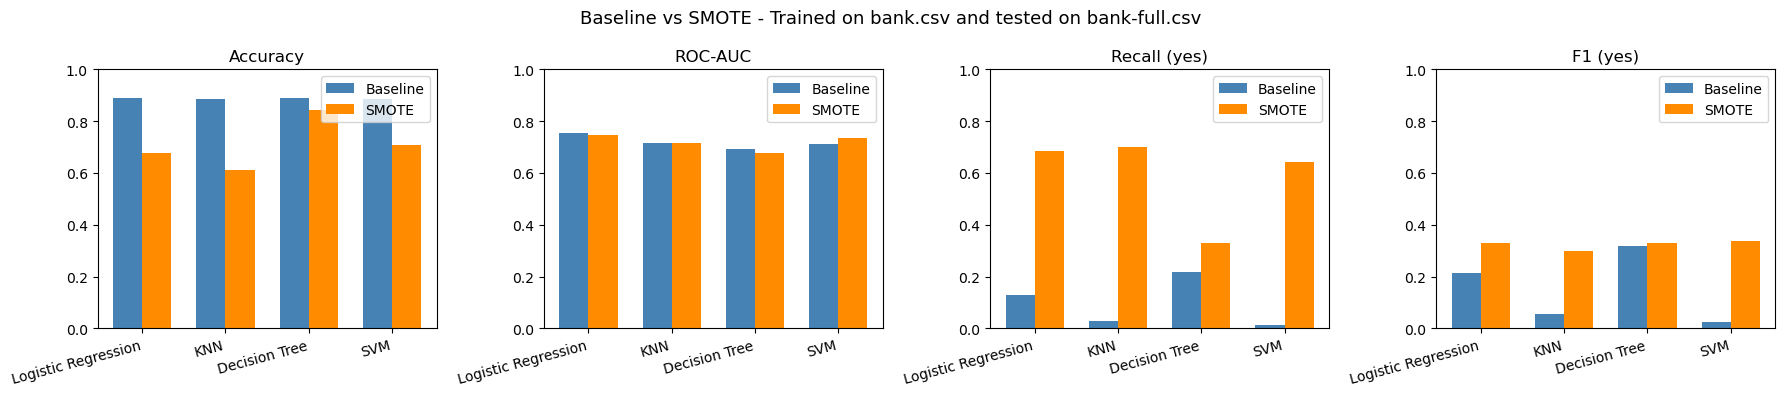

In [49]:
# Side-by-side bar chart: Baseline vs SMOTE on bank-full.csv
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'Recall (yes)', 'F1 (yes)']
model_names_full = results_full['Model'].unique()
x = np.arange(len(model_names_full))
width = 0.35

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))
fig.suptitle('Baseline vs SMOTE - Trained on bank.csv and tested on bank-full.csv', fontsize=13)

for ax, metric in zip(axes, metrics_to_plot):
    base_vals  = results_full[results_full['Type'] == 'Baseline'][metric].values
    smote_vals = results_full[results_full['Type'] == 'SMOTE'][metric].values
    ax.bar(x - width/2, base_vals,  width, label='Baseline', color='steelblue')
    ax.bar(x + width/2, smote_vals, width, label='SMOTE',    color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names_full, rotation=15, ha='right')
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()